# Тюнинг гиперпараметров

In [ ]:
!pip install optuna
import optuna
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import cross_val_score

In [ ]:
cat_features = [
    'researchDayType',
    'programAgeRestrictionName',
    'breaksPrimeTimeStatusName',
    'day_of_week',
    'month',
    'season'
]

# Копируем X_train/X_test, чтобы избежать SettingWithCopyWarning
X_train = X_train.copy()
X_test = X_test.copy()

# Приводим к category
for col in cat_features:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')


## Подбор гиперпараметров для LightGBM

In [ ]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 42,
        'n_jobs': -1
    }

    model = LGBMRegressor(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    return np.mean(score)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=1800)  # можно увеличить n_trials или timeout

print("Лучшие параметры:", study.best_params)

# Обучение с лучшими параметрами
best_model = LGBMRegressor(**study.best_params)
best_model.fit(X_train, y_train)

# Оценка
lgb_preds = best_model.predict(X_test)
lgb_r2 = r2_score(y_test, lgb_preds)

print(f"[LightGBM Optuna] R² на тестовой выборке: {lgb_r2:.5f}")
joblib.dump(best_model, f'{save_dir}/lightgbm_optuna_model.pkl')


[I 2025-05-03 14:10:00,688] A new study created in memory with name: no-name-9719fb7a-c495-40f3-8a74-49217b11cb2b
[I 2025-05-03 14:11:16,155] Trial 0 finished with value: 0.9306687299740241 and parameters: {'n_estimators': 172, 'max_depth': 4, 'learning_rate': 0.022640960374422498, 'num_leaves': 87, 'min_child_samples': 92, 'subsample': 0.6561518582088823, 'colsample_bytree': 0.9901619904796086}. Best is trial 0 with value: 0.9306687299740241.
[I 2025-05-03 14:17:08,802] Trial 1 finished with value: 0.9544043561334634 and parameters: {'n_estimators': 541, 'max_depth': 7, 'learning_rate': 0.03818407086197397, 'num_leaves': 156, 'min_child_samples': 38, 'subsample': 0.8173293953921732, 'colsample_bytree': 0.8024946852168088}. Best is trial 1 with value: 0.9544043561334634.
[I 2025-05-03 14:21:54,070] Trial 2 finished with value: 0.9567150890105823 and parameters: {'n_estimators': 394, 'max_depth': 13, 'learning_rate': 0.04991151672335993, 'num_leaves': 194, 'min_child_samples': 48, 'subs

Лучшие параметры: {'n_estimators': 394, 'max_depth': 13, 'learning_rate': 0.04991151672335993, 'num_leaves': 194, 'min_child_samples': 48, 'subsample': 0.9672112858897244, 'colsample_bytree': 0.7133333639503803}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.072729 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1576
[LightGBM] [Info] Number of data points in the train set: 1448774, number of used features: 13
[LightGBM] [Info] Start training from score 0.481988


In [ ]:
lgb_preds = best_model.predict(X_test)
lgb_r2 = r2_score(y_test, lgb_preds)
print(f"[LightGBM Optuna] R² на тестовой выборке: {lgb_r2:.5f}")

[LightGBM Optuna] R² на тестовой выборке: 0.96275


Сохраняем

In [ ]:
joblib.dump(best_model, f'{save_dir}/lightgbm_optuna_model.pkl')

['/content/drive/MyDrive/Colab Notebooks/TVR_prediction/TVR_models/lightgbm_optuna_model.pkl']

Важность признаков

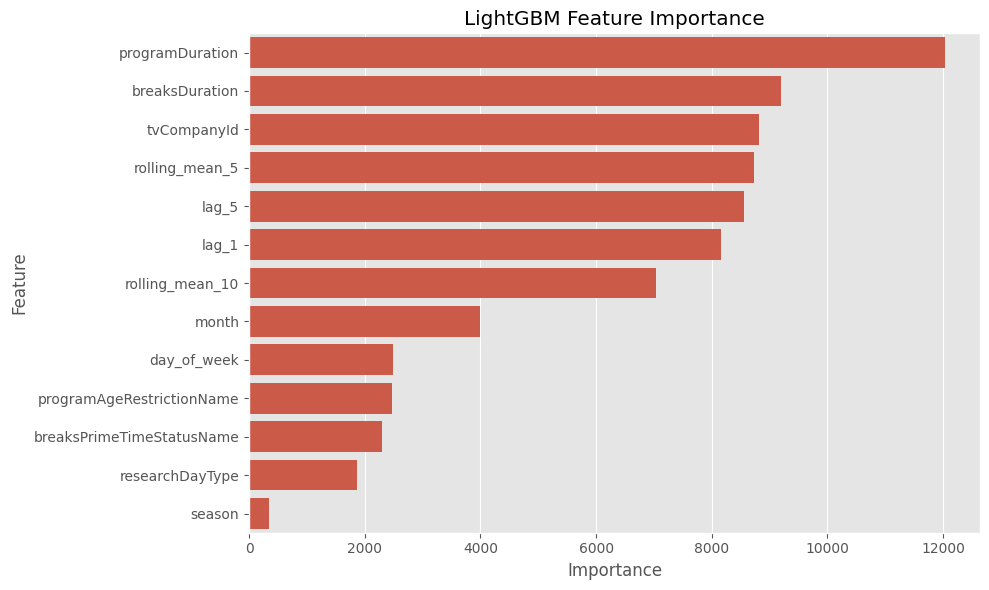

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feat_df.sort_values(by='Importance', ascending=False, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("LightGBM Feature Importance")
plt.tight_layout()
plt.show()
